In [1]:
# Week 4 - Supervised Learning Model Implementation
# Titanic Survival Prediction using Random Forest

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


In [8]:
uploaded = files.upload()

Saving titanic.csv to titanic (2).csv


In [9]:
df = pd.read_csv("titanic.csv")

print("Dataset loaded successfully!")
print("Dataset Shape:", df.shape)

display(df.head())

Dataset loaded successfully!
Dataset Shape: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [10]:
print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    object 
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    object 
 8   class        891 non-null    object 
 9   who          891 non-null    object 
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    object 
 12  embark_town  889 non-null    object 
 13  alive        891 non-null    object 
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), object(7)
memory usage: 92.4+ KB


In [11]:
print("\nStatistical Summary:")
display(df.describe(include="all"))


Statistical Summary:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
count,891.000000,891.000000,891,714.000000,891.000000,891.000000,891.000000,889,891,891,891,203,889,891,891
unique,NaN,NaN,2,NaN,NaN,NaN,NaN,3,3,3,2,7,3,2,2
top,NaN,NaN,male,NaN,NaN,NaN,NaN,S,Third,man,True,C,Southampton,no,True
freq,NaN,NaN,577,NaN,NaN,NaN,NaN,644,491,537,537,59,644,549,537
mean,0.383838,2.308642,NaN,29.699118,0.523008,0.381594,32.204208,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,0.486592,0.836071,NaN,14.526497,1.102743,0.806057,49.693429,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,1.000000,NaN,0.420000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,0.000000,2.000000,NaN,20.125000,0.000000,0.000000,7.910400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,0.000000,3.000000,NaN,28.000000,0.000000,0.000000,14.454200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1.000000,3.000000,NaN,38.000000,1.000000,0.000000,31.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
missing_values = df.isnull().sum()

print("Missing Values:")
display(missing_values[missing_values > 0])

Missing Values:


,0
age,177
embarked,2
deck,688
embark_town,2


Survival Distribution:
survived
0    549
1    342
Name: count, dtype: int64


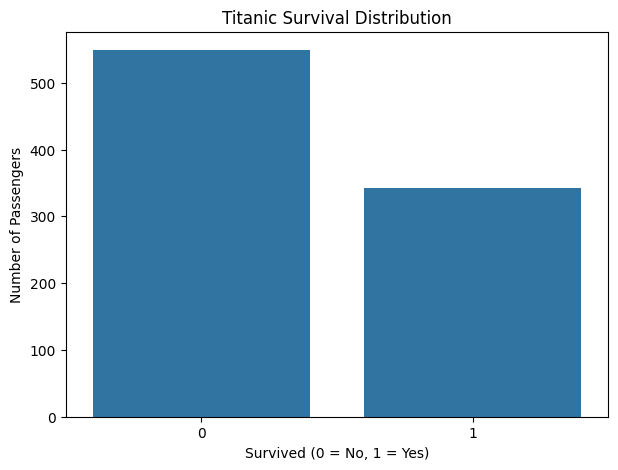

In [13]:
print("Survival Distribution:")

print(df["survived"].value_counts())

plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="survived")
plt.title("Titanic Survival Distribution")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Number of Passengers")
plt.show()

In [14]:
# Create Family Size feature
df["family_size"] = df["sibsp"] + df["parch"] + 1

# Create IsAlone feature
df["is_alone"] = (df["family_size"] == 1).astype(int)

print("Feature engineering completed.")

display(df[["sibsp", "parch", "family_size", "is_alone"]].head(10))

Feature engineering completed.


,sibsp,parch,family_size,is_alone
0,1,0,2,0
1,1,0,2,0
2,0,0,1,1
3,1,0,2,0
4,0,0,1,1
5,0,0,1,1
6,0,0,1,1
7,3,1,5,0
8,0,2,3,0
9,1,0,2,0


In [15]:
# Target variable
target = "survived"

# Features selected for prediction
features = [
    "pclass",
    "sex",
    "age",
    "sibsp",
    "parch",
    "fare",
    "embarked",
    "family_size",
    "is_alone"
]

X = df[features]
y = df[target]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

print("\nSelected Features:")
print(features)

Feature matrix shape: (891, 9)
Target shape: (891,)

Selected Features:
['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'family_size', 'is_alone']


In [16]:
numeric_features = [
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare",
    "family_size",
    "is_alone"
]

categorical_features = [
    "sex",
    "embarked"
]

print("Numerical Features:", numeric_features)
print("Categorical Features:", categorical_features)

Numerical Features: ['pclass', 'age', 'sibsp', 'parch', 'fare', 'family_size', 'is_alone']
Categorical Features: ['sex', 'embarked']


In [17]:
# Numerical preprocessing
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

# Categorical preprocessing
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

# Combine preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (712, 9)
Testing data: (179, 9)


In [19]:
random_forest = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    class_weight=None
)

print("Random Forest model created successfully!")

Random Forest model created successfully!


In [20]:
model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", random_forest)
    ]
)

print("Complete ML pipeline created!")

Complete ML pipeline created!


In [21]:
model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [22]:
y_pred = model.predict(X_test)

# Probability of survival
y_pred_proba = model.predict_proba(X_test)[:, 1]

print("Predictions generated successfully!")

print("\nFirst 10 Predictions:")
print(y_pred[:10])

Predictions generated successfully!

First 10 Predictions:
[0 0 0 0 1 0 1 1 1 0]


In [23]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Accuracy Percentage: {accuracy * 100:.2f}%")

Accuracy: 0.8045
Accuracy Percentage: 80.45%


In [24]:
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print("Model Evaluation Metrics")
print("-" * 35)
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")

Model Evaluation Metrics
-----------------------------------
Accuracy  : 0.8045
Precision : 0.8148
Recall    : 0.6377
F1-Score  : 0.7154
ROC-AUC   : 0.8407


In [25]:
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.91      0.85       110
           1       0.81      0.64      0.72        69

    accuracy                           0.80       179
   macro avg       0.81      0.77      0.78       179
weighted avg       0.81      0.80      0.80       179



Confusion Matrix:
[[100  10]
 [ 25  44]]


<Figure size 700x500 with 0 Axes>

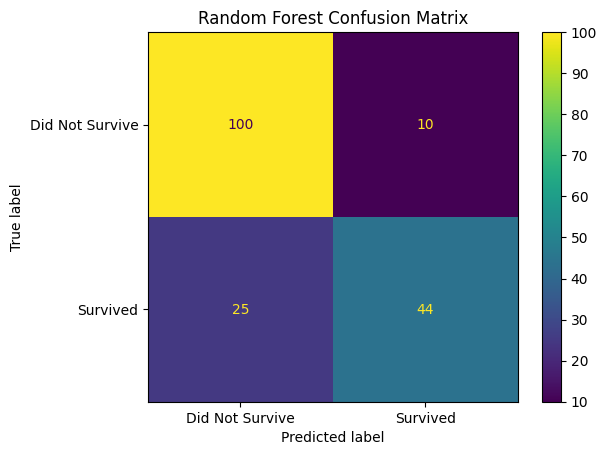

In [26]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(7, 5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Did Not Survive", "Survived"]
)

disp.plot()
plt.title("Random Forest Confusion Matrix")
plt.show()

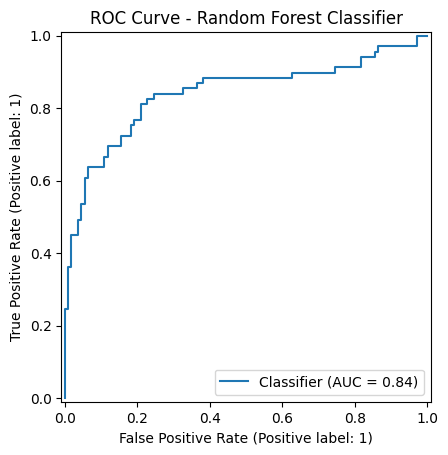

In [27]:
RocCurveDisplay.from_predictions(
    y_test,
    y_pred_proba
)

plt.title("ROC Curve - Random Forest Classifier")
plt.show()

In [28]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    model,
    X,
    y,
    cv=cv,
    scoring="accuracy"
)

print("5-Fold Cross-Validation Accuracy Scores:")
print(cv_scores)

print("\nMean Cross-Validation Accuracy:")
print(f"{cv_scores.mean():.4f}")

print("\nStandard Deviation:")
print(f"{cv_scores.std():.4f}")

5-Fold Cross-Validation Accuracy Scores:
[0.84916201 0.82022472 0.80898876 0.83146067 0.85955056]

Mean Cross-Validation Accuracy:
0.8339

Standard Deviation:
0.0185


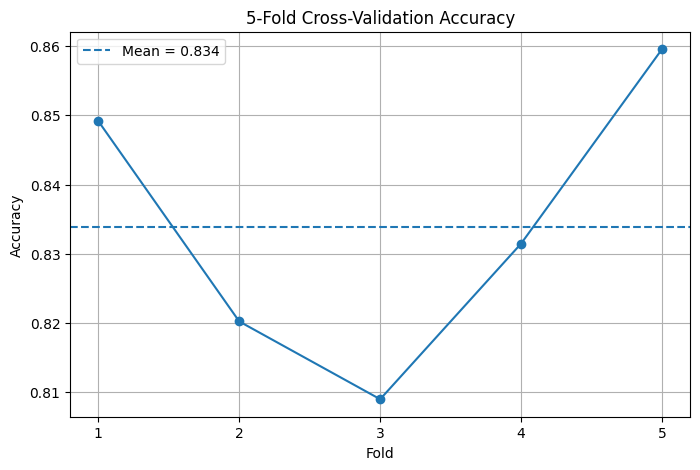

In [29]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, 6),
    cv_scores,
    marker="o"
)

plt.axhline(
    cv_scores.mean(),
    linestyle="--",
    label=f"Mean = {cv_scores.mean():.3f}"
)

plt.title("5-Fold Cross-Validation Accuracy")
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.xticks(range(1, 6))
plt.legend()
plt.grid(True)

plt.show()

In [30]:
# Get feature names after preprocessing
feature_names = model.named_steps[
    "preprocessor"
].get_feature_names_out()

# Get feature importance
importances = model.named_steps[
    "classifier"
].feature_importances_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

display(feature_importance)

,Feature,Importance
8,cat__sex_male,0.229285
7,cat__sex_female,0.187071
4,num__fare,0.178032
1,num__age,0.139299
0,num__pclass,0.111983
5,num__family_size,0.053116
2,num__sibsp,0.026974
3,num__parch,0.021954
11,cat__embarked_S,0.018680
6,num__is_alone,0.013548


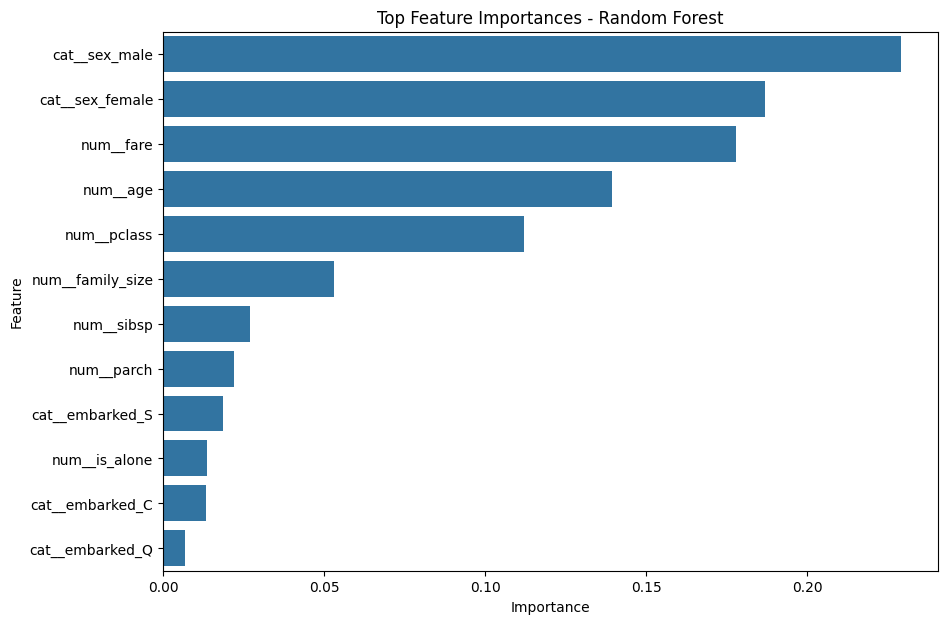

In [31]:
plt.figure(figsize=(10, 7))

sns.barplot(
    data=feature_importance.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Top Feature Importances - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [32]:
gender_survival = pd.crosstab(
    df["sex"],
    df["survived"],
    normalize="index"
) * 100

print("Survival Percentage by Gender:")
display(gender_survival)

Survival Percentage by Gender:


survived,0,1
sex,,
female,25.796178,74.203822
male,81.109185,18.890815


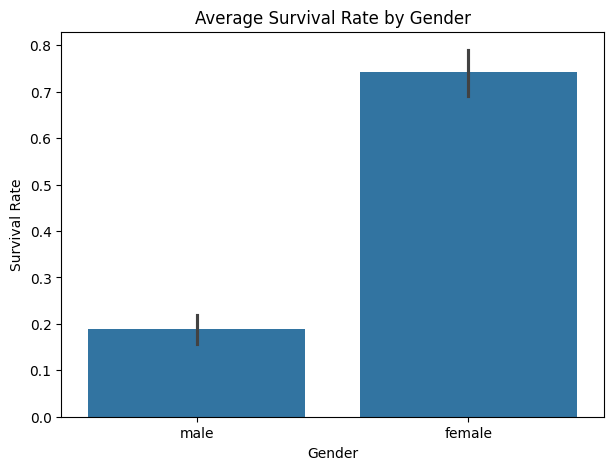

In [33]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=df,
    x="sex",
    y="survived"
)

plt.title("Average Survival Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Survival Rate")

plt.show()

In [34]:
class_survival = df.groupby("pclass")["survived"].mean() * 100

print("Survival Rate by Passenger Class:")
display(class_survival)

Survival Rate by Passenger Class:


,survived
pclass,
1,62.962963
2,47.282609
3,24.236253


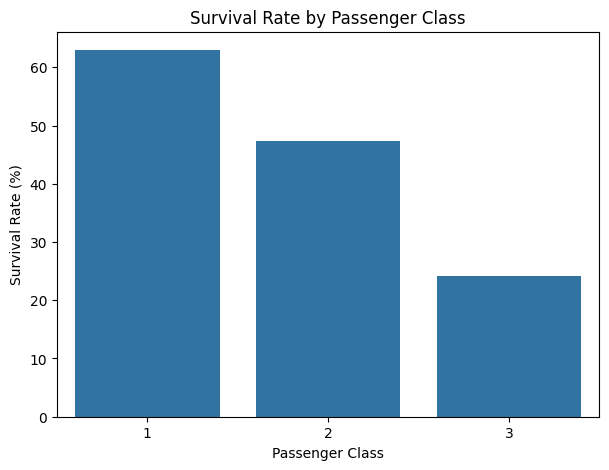

In [35]:
plt.figure(figsize=(7, 5))

sns.barplot(
    x=class_survival.index,
    y=class_survival.values
)

plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate (%)")

plt.show()

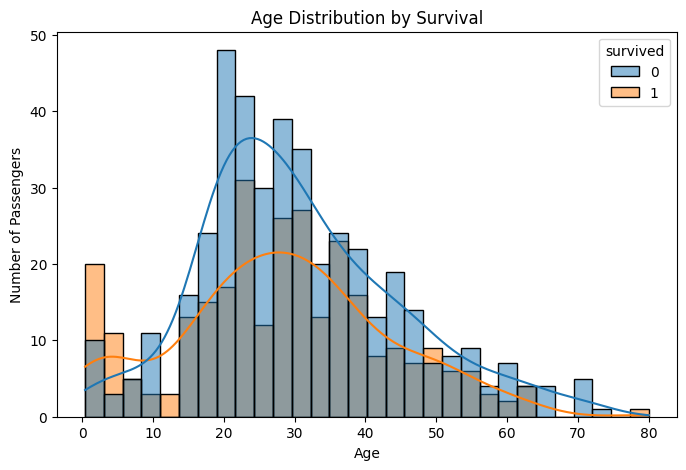

In [36]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="age",
    hue="survived",
    kde=True,
    bins=30
)

plt.title("Age Distribution by Survival")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")

plt.show()

In [37]:
performance = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC",
        "Mean CV Accuracy"
    ],
    "Score": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc,
        cv_scores.mean()
    ]
})

display(performance)

,Metric,Score
0,Accuracy,0.804469
1,Precision,0.814815
2,Recall,0.637681
3,F1-Score,0.715447
4,ROC-AUC,0.840711
5,Mean CV Accuracy,0.833877


In [38]:
results = X_test.copy()

results["Actual_Survival"] = y_test.values
results["Predicted_Survival"] = y_pred
results["Survival_Probability"] = y_pred_proba

results.to_csv(
    "titanic_predictions.csv",
    index=False
)

print("Predictions saved as titanic_predictions.csv")
display(results.head(10))

Predictions saved as titanic_predictions.csv


,pclass,sex,age,sibsp,parch,fare,embarked,family_size,is_alone,Actual_Survival,Predicted_Survival,Survival_Probability
565,3,male,24.0,2,0,24.1500,S,3,0,0,0,0.122679
160,3,male,44.0,0,1,16.1000,S,2,0,0,0,0.122607
553,3,male,22.0,0,0,7.2250,C,1,1,1,0,0.124938
860,3,male,41.0,2,0,14.1083,S,3,0,0,0,0.082613
241,3,female,NaN,1,0,15.5000,Q,2,0,1,1,0.630443
559,3,female,36.0,1,0,17.4000,S,2,0,1,0,0.390511
387,2,female,36.0,0,0,13.0000,S,1,1,1,1,0.915836
536,1,male,45.0,0,0,26.5500,S,1,1,0,1,0.526495
698,1,male,49.0,1,1,110.8833,C,3,0,0,1,0.501821
99,2,male,34.0,1,0,26.0000,S,2,0,0,0,0.118398


In [39]:
files.download("titanic_predictions.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [40]:
print("=" * 60)
print("WEEK 4 - SUPERVISED LEARNING FINAL SUMMARY")
print("=" * 60)

print(f"Dataset Size          : {df.shape}")
print(f"Training Samples      : {len(X_train)}")
print(f"Testing Samples       : {len(X_test)}")
print(f"Model                 : Random Forest Classifier")
print(f"Accuracy              : {accuracy:.4f}")
print(f"Precision             : {precision:.4f}")
print(f"Recall                : {recall:.4f}")
print(f"F1-Score              : {f1:.4f}")
print(f"ROC-AUC               : {roc_auc:.4f}")
print(f"Mean CV Accuracy      : {cv_scores.mean():.4f}")
print(f"CV Standard Deviation : {cv_scores.std():.4f}")

print("=" * 60)
print("Week 4 analysis completed successfully!")

WEEK 4 - SUPERVISED LEARNING FINAL SUMMARY
Dataset Size          : (891, 17)
Training Samples      : 712
Testing Samples       : 179
Model                 : Random Forest Classifier
Accuracy              : 0.8045
Precision             : 0.8148
Recall                : 0.6377
F1-Score              : 0.7154
ROC-AUC               : 0.8407
Mean CV Accuracy      : 0.8339
CV Standard Deviation : 0.0185
Week 4 analysis completed successfully!
